# DT01 — Chạy thẳng tiến/lùi 2 m với lệnh ±0.3

Phân tích 6 run raw ngày 22/07/2026. Notebook giữ riêng đoạn WAITING, RUNNING và BRAKING để thời gian chờ trước khi chạy không làm sai các metric chuyển động.

## Câu hỏi

Robot có dừng đúng 2 m, giữ thẳng và lặp lại được ở hai hướng không? Dữ liệu encoder, IMU, dòng motor, điện áp và timing chỉ ra lỗi nào; cần sửa gì trước lần test tiếp theo?

## Cấu hình robot

| Thuộc tính | Giá trị |
| --- | --- |
| Động cơ | REV HD Hex |
| Hộp số sử dụng | 4:1 + 4:1 |
| Tỉ số truyền thực | `13.0975:1` |
| Encoder resolution | `366.73 ticks/wheel revolution` |
| Đường kính bánh | `90 mm` |
| Khoảng cách 2 hàng bánh | `423 mm` |
| Khối lượng (ước chừng) | `3.5 kg` |
| Controller | `P_ONLY_V1`, heading `Kp = 0.012` |

In [1]:
from pathlib import Path
import sys

root = Path.cwd().resolve()
if root.name == 'notebooks':
    root = root.parent
sys.path.insert(0, str(root / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from analysis.notebook import load_test_data, setup_notebook, show_full_data
from analysis.validation import validate_data

root = setup_notebook()
data = load_test_data(root, 'DT01')
pd.set_option('display.max_columns', 100)


In [2]:
display(Markdown('## Kiểm tra dữ liệu và tạo metric theo run'))
display(validate_data(data))

wheel_diameter_mm = float(data['scenario_wheel_diameter_mm'].dropna().median())
ticks_per_wheel_rev = 366.73
mm_per_tick = np.pi * wheel_diameter_mm / ticks_per_wheel_rev
target_distance_mm = float(data['scenario_target_distance_mm'].dropna().median())

def event_row(run, token):
    rows = run[run['event'].fillna('').str.contains(token, regex=False)]
    if rows.empty:
        raise ValueError(f'{run.run_id.iloc[0]} thiếu event {token}')
    return rows.iloc[0]

def run_label(run_id, direction):
    hhmmss = run_id.split('_')[-2]
    arrow = 'F' if direction == 'FORWARD' else 'B'
    return f'{hhmmss[:2]}:{hhmmss[2:4]}:{hhmmss[4:]} {arrow}'

records = []
aligned_runs = {}
for run_id, run in data.groupby('run_id', sort=False):
    run = run.sort_values('time_s').copy()
    start = event_row(run, 'COMMAND_START')
    command_stop = event_row(run, 'TARGET_REACHED')
    stopped = event_row(run, 'STOPPED')
    direction = start['scenario_direction']
    direction_sign = 1 if direction == 'FORWARD' else -1
    motion = run[run['time_s'].between(start['time_s'], stopped['time_s'])].copy()
    moving = run[run['scenario_phase'].eq('RUNNING')].copy()
    steady = moving[moving['time_s'] >= start['time_s'] + 0.5].copy()
    label = run_label(run_id, direction)
    motion['elapsed_s'] = motion['time_s'] - start['time_s']
    motion['left_speed_m_s'] = direction_sign * motion['scenario_left_actual_tps'] * mm_per_tick / 1000
    motion['right_speed_m_s'] = direction_sign * motion['scenario_right_actual_tps'] * mm_per_tick / 1000
    motion['left_target_m_s'] = direction_sign * motion['scenario_left_target_tps'] * mm_per_tick / 1000
    motion['right_target_m_s'] = direction_sign * motion['scenario_right_target_tps'] * mm_per_tick / 1000
    motion['derived_heading_error_deg'] = start['scenario_target_heading_deg'] - motion['scenario_heading_deg']
    aligned_runs[label] = motion
    mean_target_tps = direction_sign * (moving['scenario_left_target_tps'] + moving['scenario_right_target_tps']).mean() / 2
    steady_actual_tps = direction_sign * (steady['scenario_left_actual_tps'] + steady['scenario_right_actual_tps']).mean() / 2
    final_error_mm = stopped['scenario_progress_mm'] - target_distance_mm
    heading_rmse = np.sqrt(np.mean(moving['scenario_heading_error_deg'] ** 2))
    records.append({
        'run_id': run_id,
        'run': label,
        'direction': direction,
        'wait_s': start['time_s'] - run['time_s'].iloc[0],
        'command_s': command_stop['time_s'] - start['time_s'],
        'brake_s': stopped['time_s'] - command_stop['time_s'],
        'command_stop_mm': command_stop['scenario_progress_mm'],
        'trigger_overrun_mm': command_stop['scenario_progress_mm'] - target_distance_mm,
        'post_command_motion_mm': stopped['scenario_progress_mm'] - command_stop['scenario_progress_mm'],
        'final_encoder_mm': stopped['scenario_progress_mm'],
        'final_error_mm': final_error_mm,
        'final_error_pct': 100 * final_error_mm / target_distance_mm,
        'final_lr_difference_mm': stopped['scenario_distance_difference_mm'],
        'heading_rmse_deg': heading_rmse,
        'heading_max_abs_deg': moving['scenario_heading_error_deg'].abs().max(),
        'final_heading_drift_deg': stopped['scenario_heading_deg'] - start['scenario_target_heading_deg'],
        'target_speed_m_s': mean_target_tps * mm_per_tick / 1000,
        'steady_speed_m_s': steady_actual_tps * mm_per_tick / 1000,
        'left_current_mean_a': moving['scenario_left_current_a'].mean(),
        'right_current_mean_a': moving['scenario_right_current_a'].mean(),
        'left_current_peak_a': moving['scenario_left_current_a'].max(),
        'right_current_peak_a': moving['scenario_right_current_a'].max(),
        'battery_min_v': motion['battery_v'].min(),
        'battery_drop_v': start['battery_v'] - motion['battery_v'].min(),
        'loop_dt_max_ms': run['loop_dt_ms'].max(),
        'distance_within_3pct': abs(final_error_mm) <= 0.03 * target_distance_mm,
        'heading_rmse_within_1_5deg': heading_rmse <= 1.5,
    })

metrics = pd.DataFrame(records)
metrics['screening_status'] = np.select(
    [~metrics['distance_within_3pct'], ~metrics['heading_rmse_within_1_5deg']],
    ['FAIL distance', 'FAIL heading'],
    default='PASS screen',
)
metrics.loc[~metrics['distance_within_3pct'] & ~metrics['heading_rmse_within_1_5deg'], 'screening_status'] = 'FAIL distance + heading'


## Kiểm tra dữ liệu và tạo metric theo run

,muc_do,noi_dung
0,CẢNH BÁO,Có 2 vòng lặp dài hơn 100 ms.


In [3]:
direction_counts = metrics['direction'].value_counts()
target_speed = metrics['target_speed_m_s'].median()
tps_for_0_3_m_s = 0.3 * 1000 / mm_per_tick
display(Markdown(
    f'**Phạm vi dữ liệu:** {len(metrics)} run = '
    f'{direction_counts.get("FORWARD", 0)} tiến + {direction_counts.get("BACKWARD", 0)} lùi. '
    f'Tất cả file đều ghi `trial = 1`. Lệnh `±0.3` tạo target encoder tương đương '
    f'**{target_speed:.3f} m/s**, nên `0.3` trong data là drive command, không phải 0.3 m/s. '
    f'Nếu mục tiêu vật lý thật sự là 0.3 m/s thì target xấp xỉ **{tps_for_0_3_m_s:.0f} tick/s**, không phải 714 tick/s.'
))

overview_columns = [
    'run', 'direction', 'command_s', 'final_encoder_mm', 'final_error_mm', 'final_error_pct',
    'final_lr_difference_mm', 'heading_rmse_deg', 'heading_max_abs_deg',
    'steady_speed_m_s', 'battery_min_v', 'screening_status'
]
display(metrics[overview_columns].round(3))


**Phạm vi dữ liệu:** 6 run = 4 tiến + 2 lùi. Tất cả file đều ghi `trial = 1`. Lệnh `±0.3` tạo target encoder tương đương **0.550 m/s**, nên `0.3` trong data là drive command, không phải 0.3 m/s. Nếu mục tiêu vật lý thật sự là 0.3 m/s thì target xấp xỉ **389 tick/s**, không phải 714 tick/s.

,run,direction,command_s,final_encoder_mm,final_error_mm,final_error_pct,final_lr_difference_mm,heading_rmse_deg,heading_max_abs_deg,steady_speed_m_s,battery_min_v,screening_status
0,20:55:45 F,FORWARD,4.043,2086.285,86.285,4.314,3.084,0.344,0.944,0.541,13.079,FAIL distance
1,20:56:06 B,BACKWARD,3.945,2084.358,84.358,4.218,0.771,0.358,1.053,0.544,13.066,FAIL distance
2,20:56:38 F,FORWARD,3.953,2086.671,86.671,4.334,51.656,1.676,5.547,0.545,12.734,FAIL distance + heading
3,21:15:11 F,FORWARD,3.937,2054.290,54.290,2.714,8.481,0.322,1.096,0.545,12.878,PASS screen
4,21:15:59 F,FORWARD,3.900,2075.106,75.106,3.755,8.481,0.313,1.135,0.543,12.852,FAIL distance
5,21:17:10 B,BACKWARD,3.950,2083.973,83.973,4.199,1.542,0.285,0.600,0.541,12.843,FAIL distance


## Quãng đường encoder theo thời gian

Mọi run được căn tại `COMMAND_START`; hướng lùi đã được biểu diễn bằng độ lớn quãng đường dương. Dấu tròn là lúc code phát `TARGET_REACHED|COMMAND_STOP`, dấu × là `STOPPED|END`.

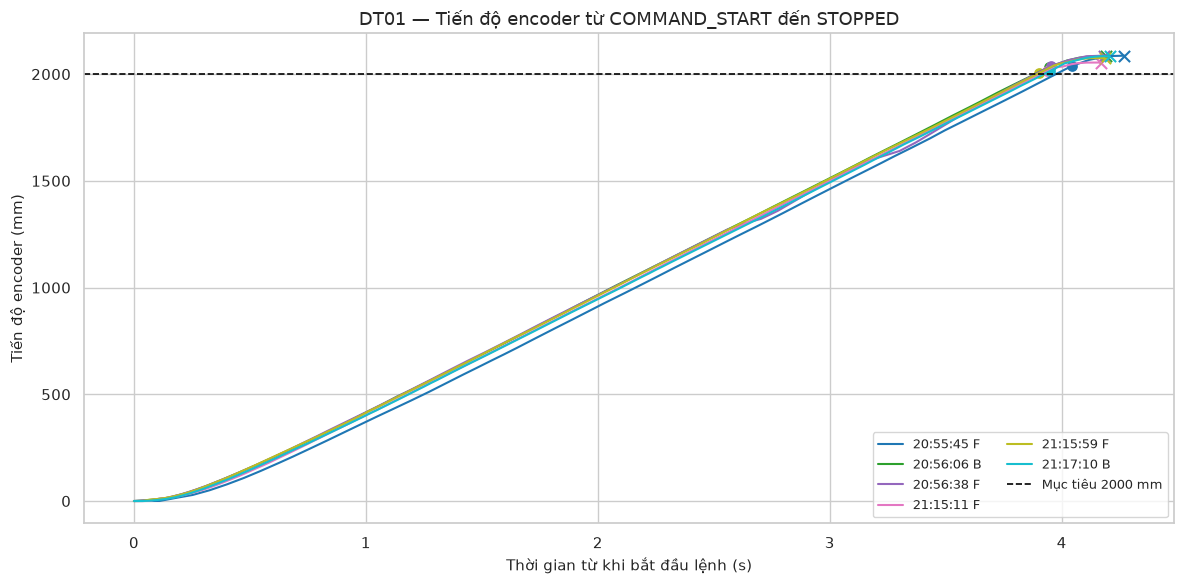

In [4]:
figure, axis = plt.subplots(figsize=(12, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(aligned_runs)))
color_by_run = dict(zip(aligned_runs, colors))
for label, motion in aligned_runs.items():
    color = color_by_run[label]
    axis.plot(motion['elapsed_s'], motion['scenario_progress_mm'], label=label, color=color)
    row = metrics.loc[metrics['run'].eq(label)].iloc[0]
    axis.scatter(row['command_s'], row['command_stop_mm'], color=color, marker='o', s=45)
    axis.scatter(row['command_s'] + row['brake_s'], row['final_encoder_mm'], color=color, marker='x', s=65)
axis.axhline(target_distance_mm, color='black', linestyle='--', linewidth=1.2, label='Mục tiêu 2000 mm')
axis.set(title='DT01 — Tiến độ encoder từ COMMAND_START đến STOPPED', xlabel='Thời gian từ khi bắt đầu lệnh (s)', ylabel='Tiến độ encoder (mm)')
axis.legend(ncol=2, fontsize=9)
figure.tight_layout()


## Theo dõi tốc độ bánh

Tốc độ lùi được đổi dấu để cùng đọc theo độ lớn. Hai đường nét đứt là target; hai đường liền là encoder thực tế.

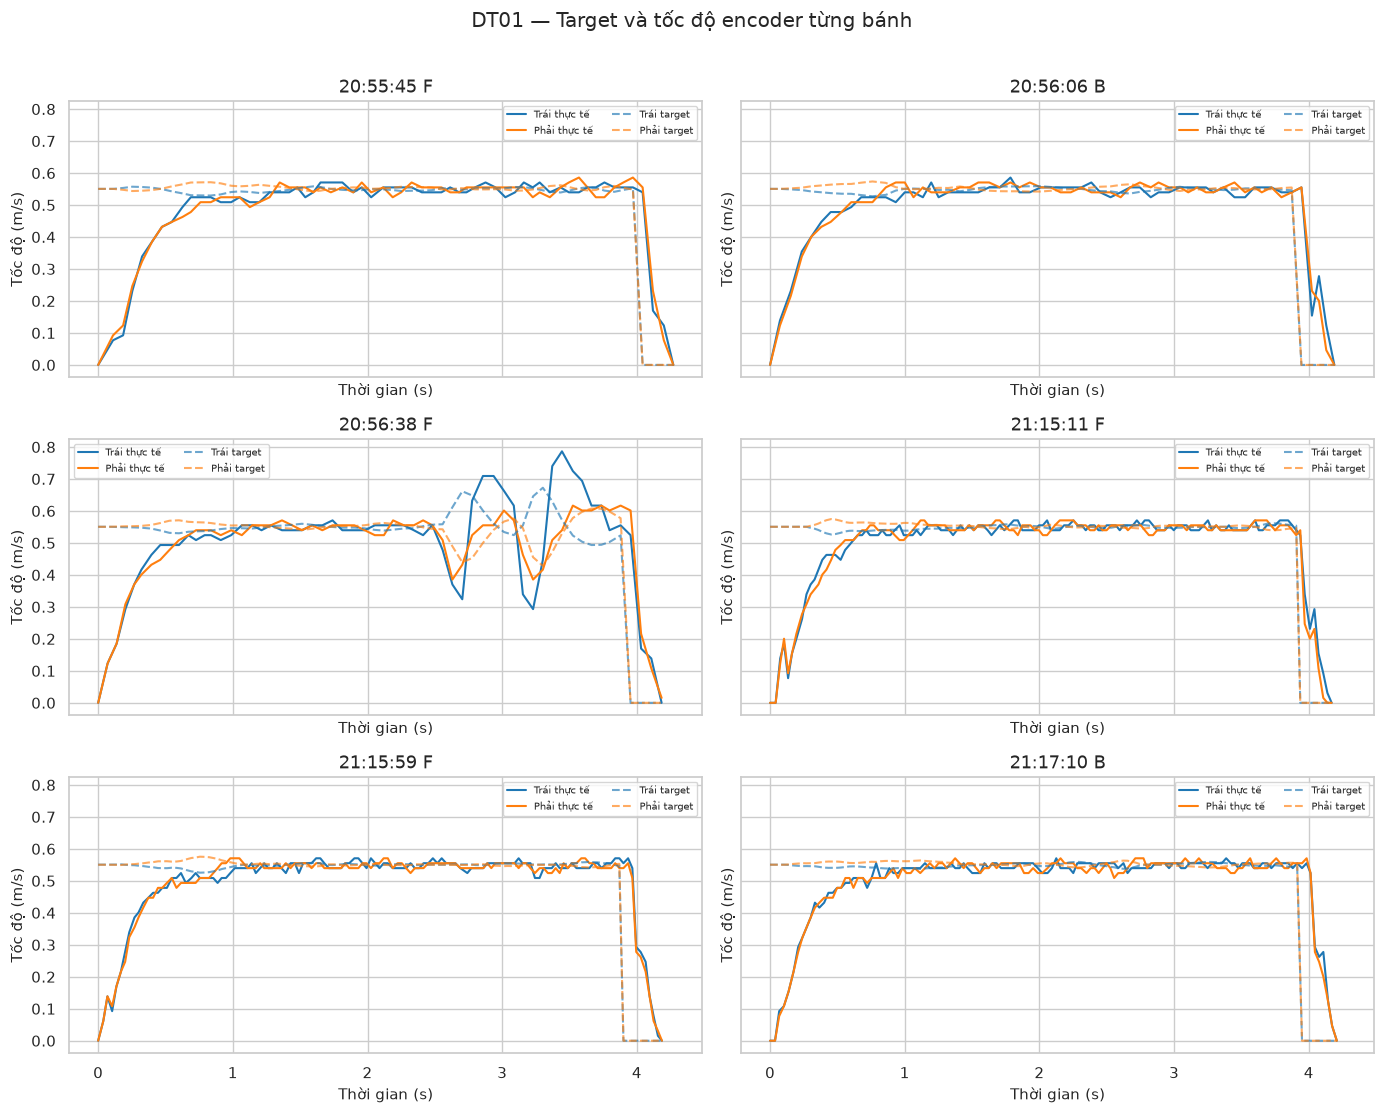

In [5]:
figure, axes = plt.subplots(3, 2, figsize=(14, 11), sharex=True, sharey=True)
for axis, (label, motion) in zip(axes.flat, aligned_runs.items()):
    axis.plot(motion['elapsed_s'], motion['left_speed_m_s'], label='Trái thực tế', color='tab:blue')
    axis.plot(motion['elapsed_s'], motion['right_speed_m_s'], label='Phải thực tế', color='tab:orange')
    axis.plot(motion['elapsed_s'], motion['left_target_m_s'], '--', label='Trái target', color='tab:blue', alpha=.65)
    axis.plot(motion['elapsed_s'], motion['right_target_m_s'], '--', label='Phải target', color='tab:orange', alpha=.65)
    axis.set(title=label, xlabel='Thời gian (s)', ylabel='Tốc độ (m/s)')
    axis.legend(fontsize=7, ncol=2)
figure.suptitle('DT01 — Target và tốc độ encoder từng bánh', y=1.01)
figure.tight_layout()


## Giữ hướng và độ đồng đều trái/phải

Sai số heading được tính lại từ heading mục tiêu đã chốt tại `COMMAND_START`, vì cột lỗi của logger bị reset về 0 ở trạng thái COMPLETE. Run 20:56:38 nổi bật rõ ở cả IMU và encoder.

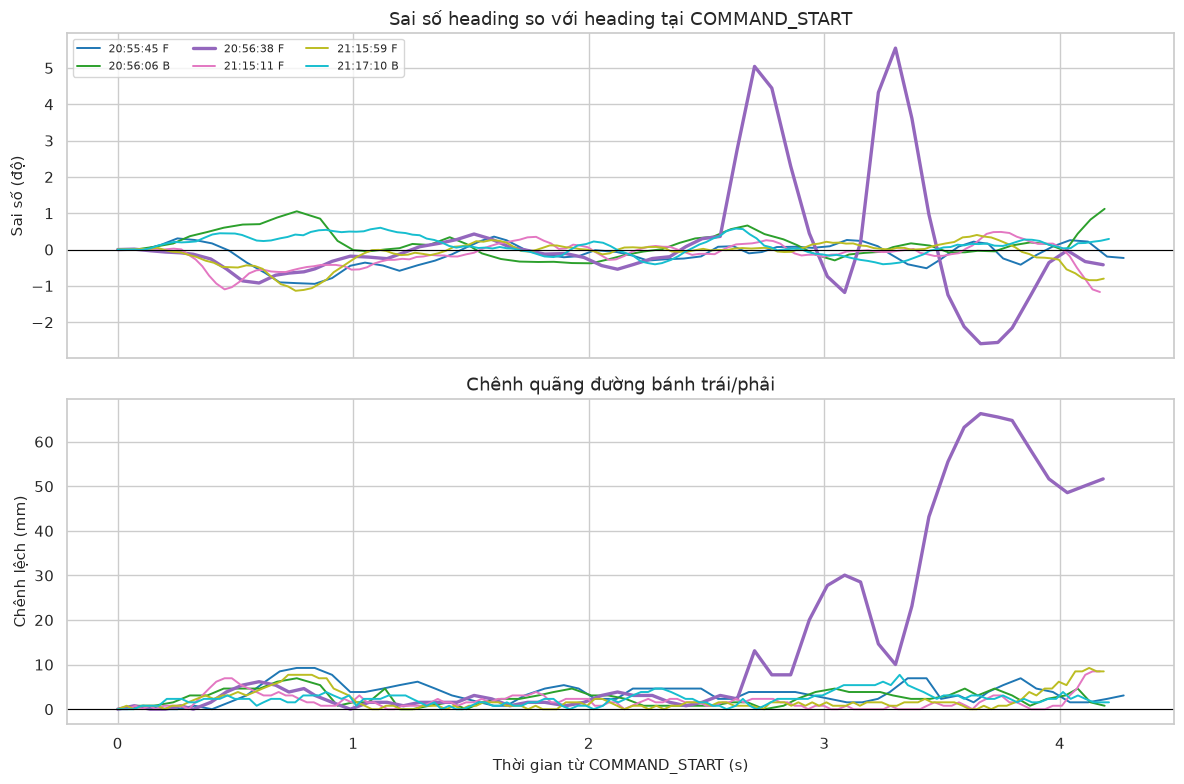

In [6]:
figure, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for label, motion in aligned_runs.items():
    color = color_by_run[label]
    width = 2.4 if label.startswith('20:56:38') else 1.4
    axes[0].plot(motion['elapsed_s'], motion['derived_heading_error_deg'], label=label, color=color, linewidth=width)
    axes[1].plot(motion['elapsed_s'], motion['scenario_distance_difference_mm'], label=label, color=color, linewidth=width)
axes[0].axhline(0, color='black', linewidth=.8)
axes[0].set(title='Sai số heading so với heading tại COMMAND_START', ylabel='Sai số (độ)')
axes[1].axhline(0, color='black', linewidth=.8)
axes[1].set(title='Chênh quãng đường bánh trái/phải', xlabel='Thời gian từ COMMAND_START (s)', ylabel='Chênh lệch (mm)')
axes[0].legend(ncol=3, fontsize=8)
figure.tight_layout()


## Dừng trễ sau mốc 2 m

Cột màu đậm là phần đã vượt 2 m khi code mới phát lệnh dừng; phần màu nhạt là quãng đường encoder tiếp tục tăng trong BRAKING. Đường đỏ 60 mm tương ứng sai số 3% của bài 2 m.

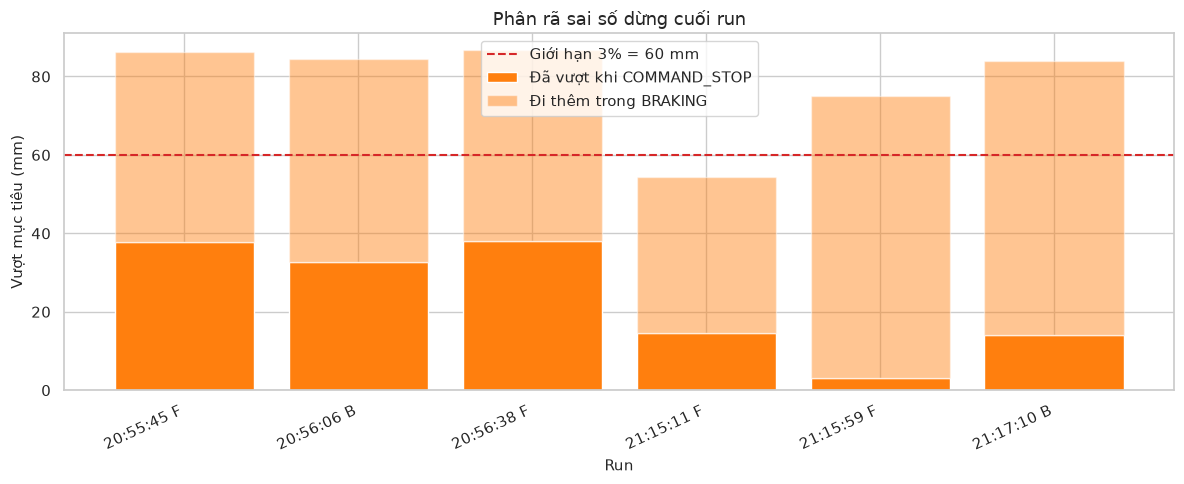

In [7]:
x = np.arange(len(metrics))
figure, axis = plt.subplots(figsize=(12, 5))
axis.bar(x, metrics['trigger_overrun_mm'], label='Đã vượt khi COMMAND_STOP', color='tab:orange')
axis.bar(x, metrics['post_command_motion_mm'], bottom=metrics['trigger_overrun_mm'], label='Đi thêm trong BRAKING', color='tab:orange', alpha=.45)
axis.axhline(0.03 * target_distance_mm, color='tab:red', linestyle='--', label='Giới hạn 3% = 60 mm')
axis.set_xticks(x, metrics['run'], rotation=25, ha='right')
axis.set(title='Phân rã sai số dừng cuối run', ylabel='Vượt mục tiêu (mm)', xlabel='Run')
axis.legend()
figure.tight_layout()


## Dòng motor và điện áp trong đoạn chạy

Mỗi màu là một run; nét liền là motor trái, nét đứt là motor phải. Tách theo thời gian từ `COMMAND_START` để thấy spike thay vì bị đoạn WAITING dài che mất.

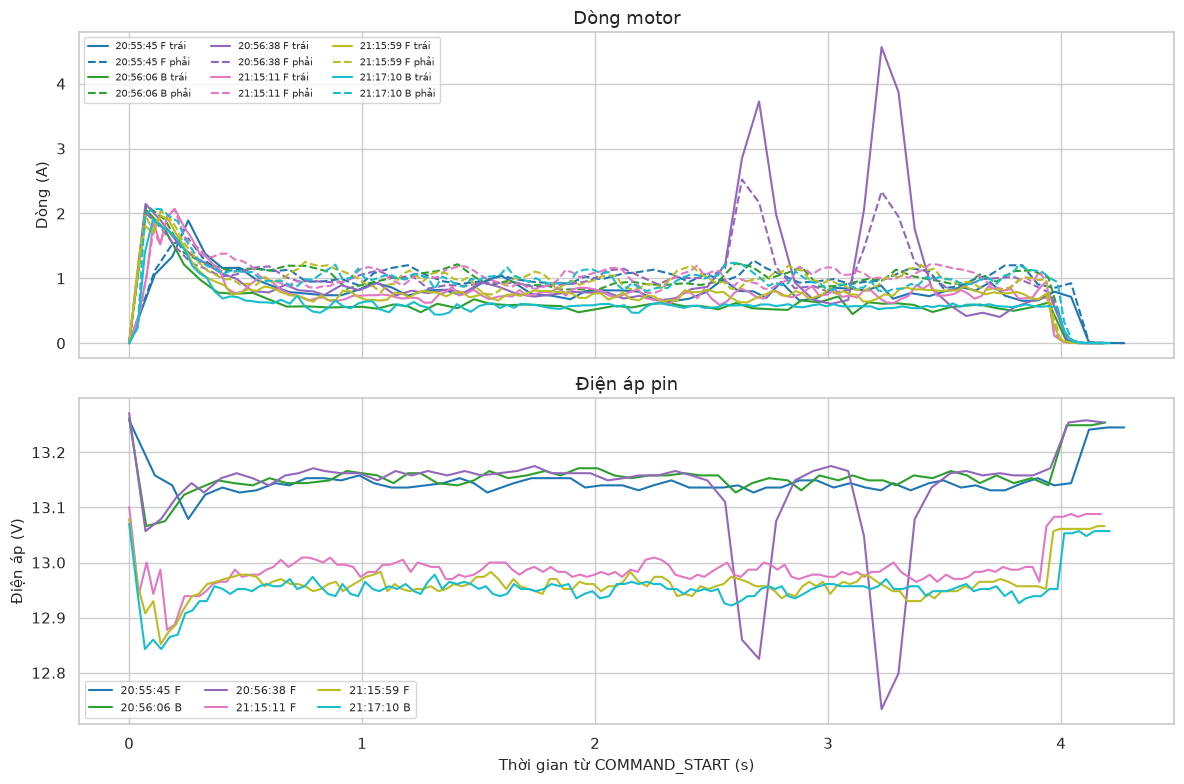

In [8]:
figure, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for label, motion in aligned_runs.items():
    color = color_by_run[label]
    axes[0].plot(motion['elapsed_s'], motion['scenario_left_current_a'], color=color, label=f'{label} trái')
    axes[0].plot(motion['elapsed_s'], motion['scenario_right_current_a'], '--', color=color, label=f'{label} phải')
    axes[1].plot(motion['elapsed_s'], motion['battery_v'], color=color, label=label)
axes[0].set(title='Dòng motor', ylabel='Dòng (A)')
axes[0].legend(ncol=3, fontsize=7)
axes[1].set(title='Điện áp pin', xlabel='Thời gian từ COMMAND_START (s)', ylabel='Điện áp (V)')
axes[1].legend(ncol=3, fontsize=8)
figure.tight_layout()


In [9]:
display(Markdown('## Tóm tắt định lượng'))
normal = metrics[~metrics['run'].str.startswith('20:56:38')]
summary = pd.DataFrame({
    'metric': [
        'Thời gian COMMAND_START → COMMAND_STOP',
        'Sai số encoder cuối run',
        'Đi thêm sau COMMAND_STOP',
        'Heading RMSE',
        'Tốc độ encoder ổn định',
        'Dòng phải − trái, bỏ run anomaly',
    ],
    'mean': [
        metrics['command_s'].mean(), metrics['final_error_mm'].mean(),
        metrics['post_command_motion_mm'].mean(), metrics['heading_rmse_deg'].mean(),
        metrics['steady_speed_m_s'].mean(),
        (normal['right_current_mean_a'] - normal['left_current_mean_a']).mean(),
    ],
    'min': [
        metrics['command_s'].min(), metrics['final_error_mm'].min(),
        metrics['post_command_motion_mm'].min(), metrics['heading_rmse_deg'].min(),
        metrics['steady_speed_m_s'].min(),
        (normal['right_current_mean_a'] - normal['left_current_mean_a']).min(),
    ],
    'max': [
        metrics['command_s'].max(), metrics['final_error_mm'].max(),
        metrics['post_command_motion_mm'].max(), metrics['heading_rmse_deg'].max(),
        metrics['steady_speed_m_s'].max(),
        (normal['right_current_mean_a'] - normal['left_current_mean_a']).max(),
    ],
    'unit': ['s', 'mm', 'mm', 'deg', 'm/s', 'A'],
})
display(summary.round(3))


## Tóm tắt định lượng

,metric,mean,min,max,unit
0,Thời gian COMMAND_START → COMMAND_STOP,3.955,3.900,4.043,s
1,Sai số encoder cuối run,78.447,54.290,86.671,mm
2,Đi thêm sau COMMAND_STOP,55.061,39.706,72.087,mm
3,Heading RMSE,0.550,0.285,1.676,deg
4,Tốc độ encoder ổn định,0.543,0.541,0.545,m/s
5,"Dòng phải − trái, bỏ run anomaly",0.287,0.190,0.395,A


## Vấn đề tôi thấy từ dữ liệu và hướng xử lý

### 1. Vấn đề chính: robot dừng trễ, không phải thiếu quãng đường

- Cả 6 run đều kết thúc dài hơn encoder target: **+54.3 đến +86.7 mm**, trung bình **+78.4 mm (3.92%)**. Với ngưỡng ±3% cho bài 2 m, **5/6 run không đạt**. Bỏ run anomaly 20:56:38 vẫn còn trung bình +76.8 mm, nên đây là lỗi hệ thống chứ không do một lần chạy xấu.
- Khi `COMMAND_STOP` được ghi, robot đã vượt target trung bình 23.4 mm; sau đó còn đi thêm trung bình 55.1 mm trong 0.23–0.29 s. Control đang chờ đến 2 m mới đưa command về 0, nên quán tính và độ trễ vòng lặp chắc chắn tạo overshoot.
- **Đề xuất:** không tăng/giảm heading Kp để chữa lỗi quãng đường. Trước mắt, với đúng cấu hình và mặt sân này, thử phát lệnh giảm tốc sớm khoảng 60–80 mm để xác nhận cơ chế. Bản sửa bền vững hơn là dùng velocity profile theo quãng đường còn lại (trapezoid/S-curve), đo gia tốc phanh rồi giới hạn `v_cmd <= sqrt(2*a_brake*remaining)`; bật/kiểm tra brake mode và giữ vòng position/velocity nhỏ ở cuối. Retest và hiệu chỉnh bằng khoảng cách đo ngoài robot, không chỉ encoder.

### 2. Run 20:56:38 có nhiễu cơ khí/ngoại lực hoặc lỗi cảm biến rõ ràng

- Run này có chênh quãng đường hai bên cuối run **51.7 mm**; 5 run còn lại chỉ **0.8–8.5 mm**. Heading RMSE **1.68°**, đỉnh **5.55°**; yaw-rate đạt khoảng **62.9°/s**. Cùng thời điểm, dòng trái lên **4.56 A**, chênh tốc độ bánh tức thời tới **320 tick/s**, pin xuống **12.734 V**. Các tín hiệu độc lập cùng biến động nên không nên xem đây chỉ là nhiễu IMU.
- **Đề xuất:** đánh dấu run này là `anomaly candidate`, đối chiếu video/mặt sân tại khoảng 2.6–3.5 s sau `COMMAND_START`, kiểm tra bánh/cụm truyền động trái, encoder và giắc nguồn. Chỉ loại khỏi thống kê chính khi manifest có lý do; vẫn giữ file raw. Chạy bù sau kiểm tra cơ khí. Không tune P-only dựa riêng trên run này.

### 3. “Speed 0.3” đang không có cùng nghĩa giữa yêu cầu và log

- `scenario_drive_command = ±0.3`, nhưng target là khoảng **714 tick/s = 0.550 m/s** với bánh 90 mm và 366.73 tick/vòng; tốc độ encoder ổn định đo được khoảng **0.543 m/s**.
- **Đề xuất:** nếu 0.3 nghĩa là 30% command, đổi tên bài/nhãn plot thành “drive command 0.3”. Nếu yêu cầu là **0.3 m/s**, target đúng xấp xỉ **389 tick/s** và phải chạy lại toàn bộ block. Ghi cả `command_normalized` và `target_velocity_m_s` trong metadata để không lẫn đơn vị.

### 4. Motor phải dùng dòng cao hơn một cách lặp lại

- Bỏ run anomaly, dòng RUNNING trung bình bên phải cao hơn bên trái khoảng **0.29 A**; xu hướng có ở cả tiến và lùi. Tốc độ ổn định vẫn khá sát target, nên đây là dấu hiệu cần kiểm tra, chưa đủ để kết luận motor hỏng.
- **Đề xuất:** so lại với DT00, kiểm tra ma sát bánh/bạc đạn/gear mesh và căng xích bên phải; xác minh calibration hai cảm biến dòng. Nếu có thể, đổi chéo motor/port trong một test có kiểm soát để xem chênh dòng đi theo cơ khí hay kênh điện.

### 5. Thiết kế và log chưa đủ để khẳng định độ chính xác ngoài thực tế

- Có 6 run nhưng phân bố **4 tiến/2 lùi**, và tất cả ghi `trial = 1`. Hai vòng lặp đầu buổi dài hơn 100 ms; thời gian WAITING dao động 0.87–58.76 s. Encoder chỉ cho biết quãng đường bánh, không chứng minh robot thật sự đi đúng 2 m hay không trượt/lệch ngang.
- **Đề xuất:** dùng trial duy nhất 1…N, chốt trước số run cân bằng theo hướng, tách timing control khỏi ghi CSV nếu cùng loop, và ghi phép đo ngoài (AprilTag/thước chuẩn: quãng đường thật, lệch ngang, heading cuối). Chỉ sau đó mới hiệu chuẩn wheel diameter/effective ticks-per-meter và đặt tiêu chí pass chính thức.

**Quyết định hiện tại:** chưa coi DT01 đạt. Sửa profile dừng và làm rõ đơn vị tốc độ trước; điều tra/chạy bù run 20:56:38; kiểm tra chênh dòng bên phải; sau đó chạy lại một block cân bằng có đo vị trí ngoài robot.

In [10]:
show_full_data(data)


## Dữ liệu đầy đủ

,schema_version,run_id,scenario_id,configuration_id,trial,sample_index,time_s,loop_dt_ms,event,battery_v,scenario_phase,scenario_direction,scenario_controller_version,scenario_target_distance_mm,scenario_left_distance_mm,scenario_right_distance_mm,scenario_progress_mm,scenario_remaining_mm,scenario_distance_difference_mm,scenario_drive_command,scenario_target_heading_deg,scenario_heading_deg,scenario_heading_error_deg,scenario_heading_kp,scenario_heading_p,scenario_yaw_rate_deg_s,scenario_left_target_tps,scenario_right_target_tps,scenario_left_actual_tps,scenario_right_actual_tps,scenario_left_position_ticks,scenario_right_position_ticks,scenario_left_current_a,scenario_right_current_a,scenario_stopped,scenario_gear_reduction,scenario_wheel_diameter_mm,scenario_track_width_mm,source_file
0,fgc-ts-v1,DT01_move_straight_20260722_205545_561,DT01,DT01_P_ONLY_V1,1,0,0.022731,22.731044,LOG_START,13.254,WAITING,NONE,P_ONLY_V1,2000.0,-0.000000,0.000000,0.000000,2000.000000,0.000000,0.0,0.000000,0.026331,0.0,0.012,0.0,3.197711,0.0,0.0,220.0,200.0,-34185,61111,0.000,0.000,False,13.0975,90.0,423.0,DT01_move_straight_20260722_205545_561.csv
1,fgc-ts-v1,DT01_move_straight_20260722_205545_561,DT01,DT01_P_ONLY_V1,1,1,0.110855,88.123884,NaN,13.249,WAITING,NONE,P_ONLY_V1,2000.0,-0.000000,0.000000,0.000000,2000.000000,0.000000,0.0,0.000000,0.349054,0.0,0.012,0.0,4.544116,0.0,0.0,220.0,180.0,-34166,61126,0.003,0.003,False,13.0975,90.0,423.0,DT01_move_straight_20260722_205545_561.csv
2,fgc-ts-v1,DT01_move_straight_20260722_205545_561,DT01,DT01_P_ONLY_V1,1,2,0.183308,72.453216,NaN,13.249,WAITING,NONE,P_ONLY_V1,2000.0,-0.000000,0.000000,0.000000,2000.000000,0.000000,0.0,0.000000,0.715686,0.0,0.012,0.0,5.385618,0.0,0.0,220.0,160.0,-34150,61139,0.000,0.003,False,13.0975,90.0,423.0,DT01_move_straight_20260722_205545_561.csv
3,fgc-ts-v1,DT01_move_straight_20260722_205545_561,DT01,DT01_P_ONLY_V1,1,3,0.247912,64.604173,NaN,13.249,WAITING,NONE,P_ONLY_V1,2000.0,-0.000000,0.000000,0.000000,2000.000000,0.000000,0.0,0.000000,0.988717,0.0,0.012,0.0,3.197711,0.0,0.0,160.0,140.0,-34139,61147,0.000,0.003,False,13.0975,90.0,423.0,DT01_move_straight_20260722_205545_561.csv
4,fgc-ts-v1,DT01_move_straight_20260722_205545_561,DT01,DT01_P_ONLY_V1,1,4,0.315989,68.076757,NaN,13.254,WAITING,NONE,P_ONLY_V1,2000.0,-0.000000,0.000000,0.000000,2000.000000,0.000000,0.0,0.000000,1.076800,0.0,0.012,0.0,-0.673202,0.0,0.0,60.0,60.0,-34131,61154,0.000,0.003,False,13.0975,90.0,423.0,DT01_move_straight_20260722_205545_561.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2961,fgc-ts-v1,DT01_move_straight_20260722_211710_846,DT01,DT01_P_ONLY_V1,1,186,6.013400,31.044419,NaN,13.057,BRAKING,BACKWARD,P_ONLY_V1,2000.0,2067.010856,2070.094797,2068.552826,-68.552826,3.083940,0.0,-0.001581,-0.176028,0.0,0.012,0.0,-0.168301,0.0,0.0,-340.0,-320.0,6274,4689,0.007,0.014,False,13.0975,90.0,423.0,DT01_move_straight_20260722_211710_846.csv
2962,fgc-ts-v1,DT01_move_straight_20260722_211710_846,DT01,DT01_P_ONLY_V1,1,187,6.044910,31.509337,NaN,13.048,BRAKING,BACKWARD,P_ONLY_V1,2000.0,2075.491692,2077.804647,2076.648169,-76.648169,2.312955,0.0,-0.001581,-0.183731,0.0,0.012,0.0,-2.608659,0.0,0.0,-360.0,-260.0,6263,4679,0.003,0.003,False,13.0975,90.0,423.0,DT01_move_straight_20260722_211710_846.csv
2963,fgc-ts-v1,DT01_move_straight_20260722_211710_846,DT01,DT01_P_ONLY_V1,1,188,6.080039,35.129212,NaN,13.057,BRAKING,BACKWARD,P_ONLY_V1,2000.0,2080.888587,2082.430557,2081.659572,-81.659572,1.541970,0.0,-0.001581,-0.220083,0.0,0.012,0.0,-0.084150,0.0,0.0,-160.0,-160.0,6256,4673,0.000,0.003,False,13.0975,90.0,423.0,DT01_move_straight_20260722_211710_846.csv
2964,fgc-ts-v1,DT01_move_straight_20260722_211710_846,DT01,DT01_P_ONLY_V1,1,189,6.110093,30.054211,NaN,13.057,BRAKING,BACKWARD,P_ONLY_V1,2000.0,2083.201542,2084.743512,2083.972527,-83.972527,1.541970,0.0,-0.001581,-0.243591,0.0,0.012,0.0,-2.27205